## 0. PHÁT BIỂU BÀI TOÁN
- Phân tích dữ liệu nhằm khảo sát tính khả thi cho việc xây dựng mô hình dự đoán lượng CO2 phát thải trong năm của 1 nước dựa trên các biến đặc trưng sau:
    + coal-lignite (Lượng than đá tiêu thụ trong năm)
    + electricity (Lượng điện tiêu thụ trong năm)
    + natural-gas (Lượng khí gas tiêu thụ trong năm)
    + oil-products (Lượng sản phẩm từ dầu tiêu thụ trong năm)
    + renewables (Phần trăm điện năng được tạo ra bằng năng lượng tái tạo trong năm)
    + renewables-wind-solar (Phần trăm điện năng được tạo ra bằng năng lượng tái tạo gió và mặt trời trong năm)
    + total-energy (Tổng năng lượng tiêu thụ trong năm)
- Vì biến mục tiêu Y (Lượng phát thải CO2) là một biến số thực nên việc mô hình hóa này thuộc bài toán Hồi quy (Regression).
- Bài toán được đặt ra là khả thi (về dữ liệu) để xây dựng mô hình dự đoán, dựa trên các cơ sở sau:
    + Dữ liệu có kích thước 1681 mẫu và 7 đặc trưng, đủ lớn để thực hiện các thuật toán Hồi quy mà không bị hiện tượng overfitting do thiếu mẫu
    + Chất lượng dữ liệu được đảm bảo: Các vấn đề về giá trị NaN, Outliers đã được xử lý tại bước làm sạch dữ liệu,
    + Lượng thông tin dự báo tốt: Phân tích ma trận tương quan (Pearson/Spearman) cho thấy có một số biến đặc trưng (như X1, X2...) có hệ số tương quan tuyến tính rõ rệt với biến mục tiêu Y. Điều này chứng tỏ đặc trưng mang tín hiệu dự đoán tốt (Được chứng minh tại mục 5. Mối quan hệ giữa các biến dữ liệu)
- Tập đặc trưng hữu ích có thể dùng để xây dựng mô hình là: 
    + coal-lignite 
    + electricity 
    + natural-gas
    + oil-products
    + total-energy

## 1. THU THẬP DỮ LIỆU
- Nguồn dữ liệu: https://yearbook.enerdata.net
- Dữ liệu thu thập bao gồm 8 loại năng lượng tiêu thụ của 48 quốc gia từ năm 1990-2024
    + coal-lignite (Lượng than đá tiêu thụ trong năm) : (https://yearbook.enerdata.net/coal-lignite/coal-world-consumption-data.html)
    + electricity (Lượng điện tiêu thụ trong năm) : (https://yearbook.enerdata.net/electricity/electricity-domestic-consumption-data.html)
    + natural-gas (Lượng khí gas tiêu thụ trong năm) : (https://yearbook.enerdata.net/natural-gas/gas-consumption-data.html)
    + oil-products (Lượng sản phẩm từ dầu tiêu thụ trong năm) : (https://yearbook.enerdata.net/oil-products/world-oil-domestic-consumption-statistics.html)
    + renewables (Phần trăm điện năng được tạo ra bằng năng lượng tái tạo trong năm) : (https://yearbook.enerdata.net/renewables/renewable-in-electricity-production-share.html)
    + renewables-wind-solar (Phần trăm điện năng được tạo ra bằng năng lượng tái tạo gió và mặt trời trong năm) : (https://yearbook.enerdata.net/renewables/wind-solar-share-electricity-production.html)
    + total-energy (Tổng năng lượng tiêu thụ trong năm) : (https://yearbook.enerdata.net/total-energy/world-consumption-statistics.html)
    + co2-emissions: Lượng CO2 phát thải trong năm (https://yearbook.enerdata.net/co2/emissions-co2-data-from-fuel-combustion.html)
- Trang web cung cấp API có dạng: https://api-yearbook.enerdata.net/values?fullCode%5B0%5D={full_code}&zoneCode%5B0%5D={zone_code}&pagination=false&locale=en (Mở F12 nhấn Tab Networks rồi nhấn từng trang dữ liệu muốn xem sẽ phát hiện được API của trang cung cấp)
    + full_code là mã code để truy cập đến trang nhiên liệu tương ứng
    + zone_code là mã quốc gia 
- Các bước thực hiện đã được làm ở file full_data_crawler.ipynb
- Dữ liệu thô sau khi thu thập được lưu ở: raw data/raw_data.jsonl

### Xuất ra một số thông tin về tập dữ liệu thu được:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

In [4]:
data_file_path = 'processed/processed_data.csv'
data_frame = pd.read_csv(data_file_path)

In [ ]:
data_table = data_frame.pivot_table(index=['Country', 'Year'],columns='Type',values='Value')
unit = data_frame[['Type', 'Unit']].drop_duplicates().set_index('Type').to_dict()['Unit']
type_data = data_table.columns.get_level_values(0).drop_duplicates().to_list()
country = data_table.index.get_level_values(0).drop_duplicates().to_list()

In [6]:
unit

{'total-energy': 'Mtep',
 'coal-lignite': 'Mt',
 'oil-products': 'Mt',
 'natural-gas': 'Gm3',
 'electricity': 'TWh',
 'renewables': '%',
 'renewables-wind-solar': '%',
 'co2-emissions': 'MtCO2'}

In [7]:
type_data

['co2-emissions',
 'coal-lignite',
 'electricity',
 'natural-gas',
 'oil-products',
 'renewables',
 'renewables-wind-solar',
 'total-energy']

In [15]:
data_table.to_csv("clean_data.csv",index=True)
df = pd.read_csv('clean_data.csv')
df

,Country,Year,co2-emissions,coal-lignite,electricity,natural-gas,oil-products,renewables,renewables-wind-solar,total-energy
0,Algeria,1990,50.118890,1.065000,12.555000,14.602868,8.072359,0.838301,0.000000,21.166734
1,Algeria,1991,53.221121,1.042000,12.868000,15.804842,8.484124,1.689248,0.000000,23.165670
2,Algeria,1992,55.906245,0.975000,13.962000,16.234184,9.088171,1.088264,0.000000,24.170773
3,Algeria,1993,58.585925,0.779000,13.905000,18.928921,8.416735,1.818182,0.000000,26.026684
4,Algeria,1994,57.655106,0.882000,14.251000,19.120842,7.718124,0.834674,0.000000,27.025515
...,...,...,...,...,...,...,...,...,...,...
1675,Vietnam,2020,306.554358,101.963268,215.743000,8.970158,21.062792,35.557388,4.327714,101.219157
1676,Vietnam,2021,288.652757,99.313080,223.528557,7.601025,18.933276,44.127725,12.282918,103.412281
1677,Vietnam,2022,289.006827,95.222535,225.448181,8.299373,26.092425,49.089093,12.836926,105.792257
1678,Vietnam,2023,341.059719,118.013299,235.159827,7.670531,26.988333,39.986927,12.716901,115.765929


### Xuất ra các thống kê mô tả trực quan về dữ liệu đơn biến đối với một vài biến quan trọng

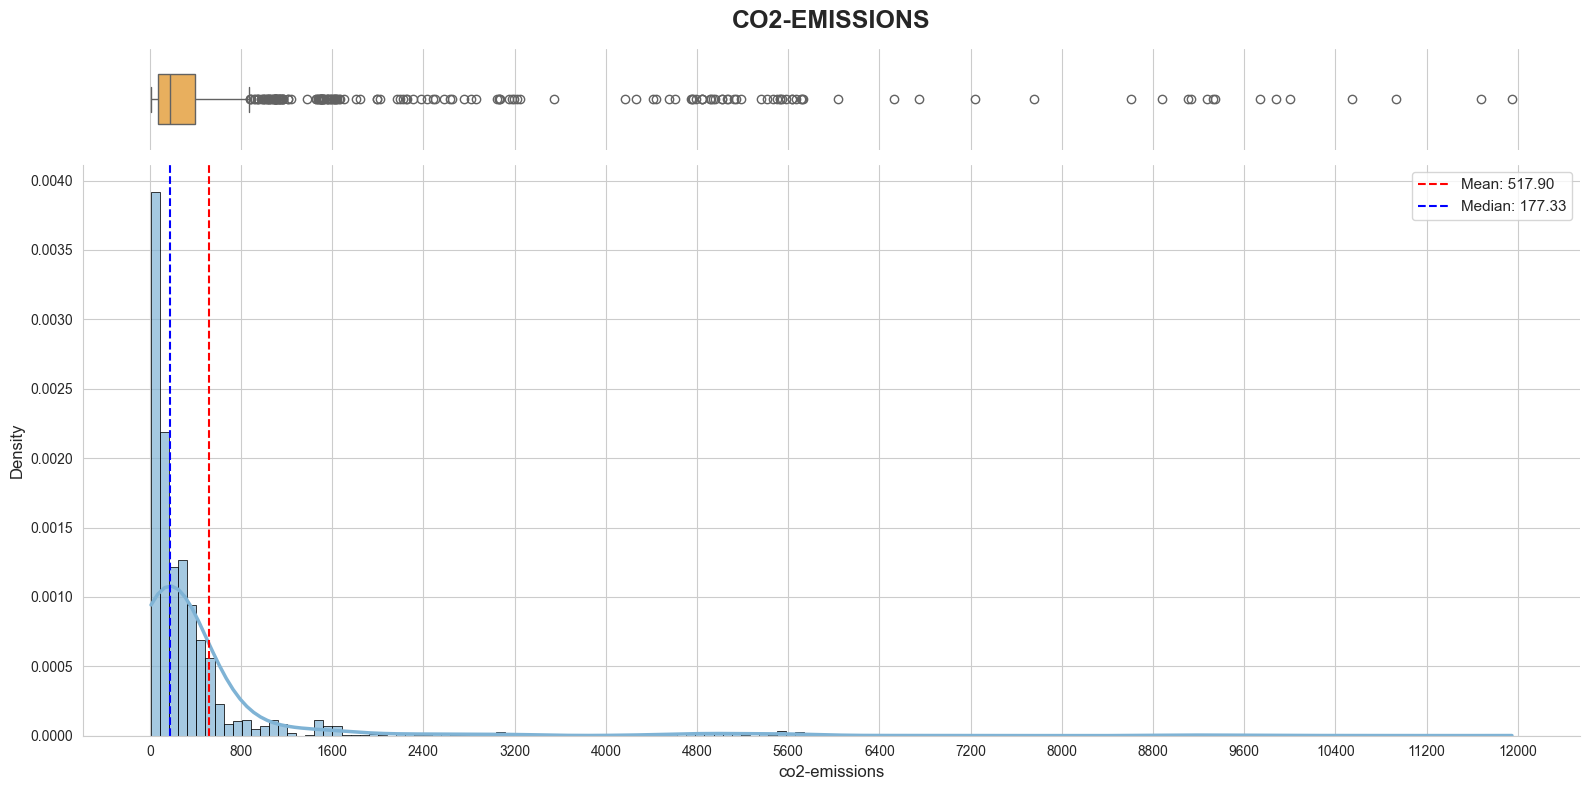

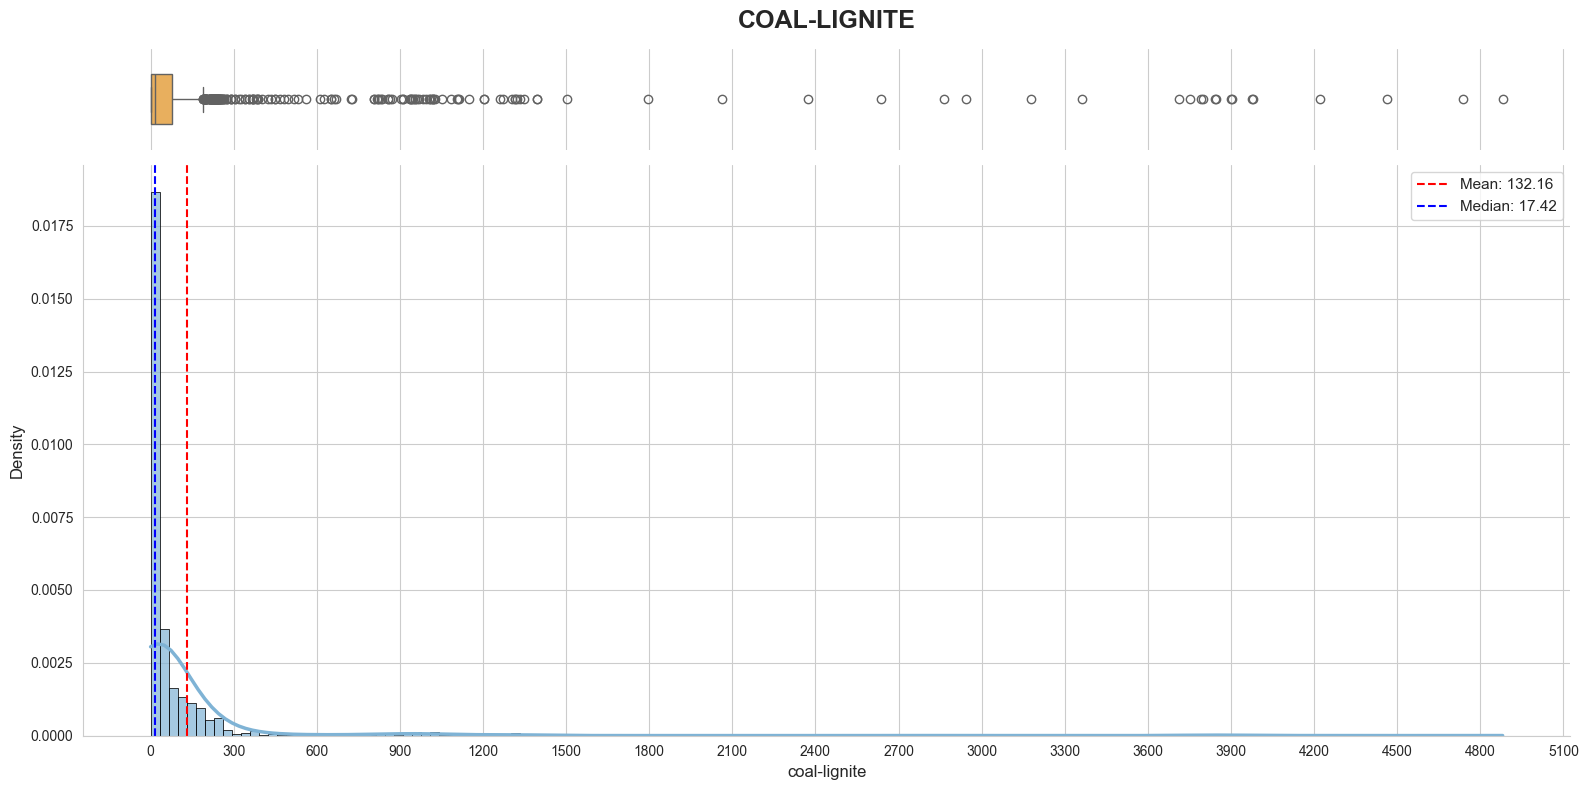

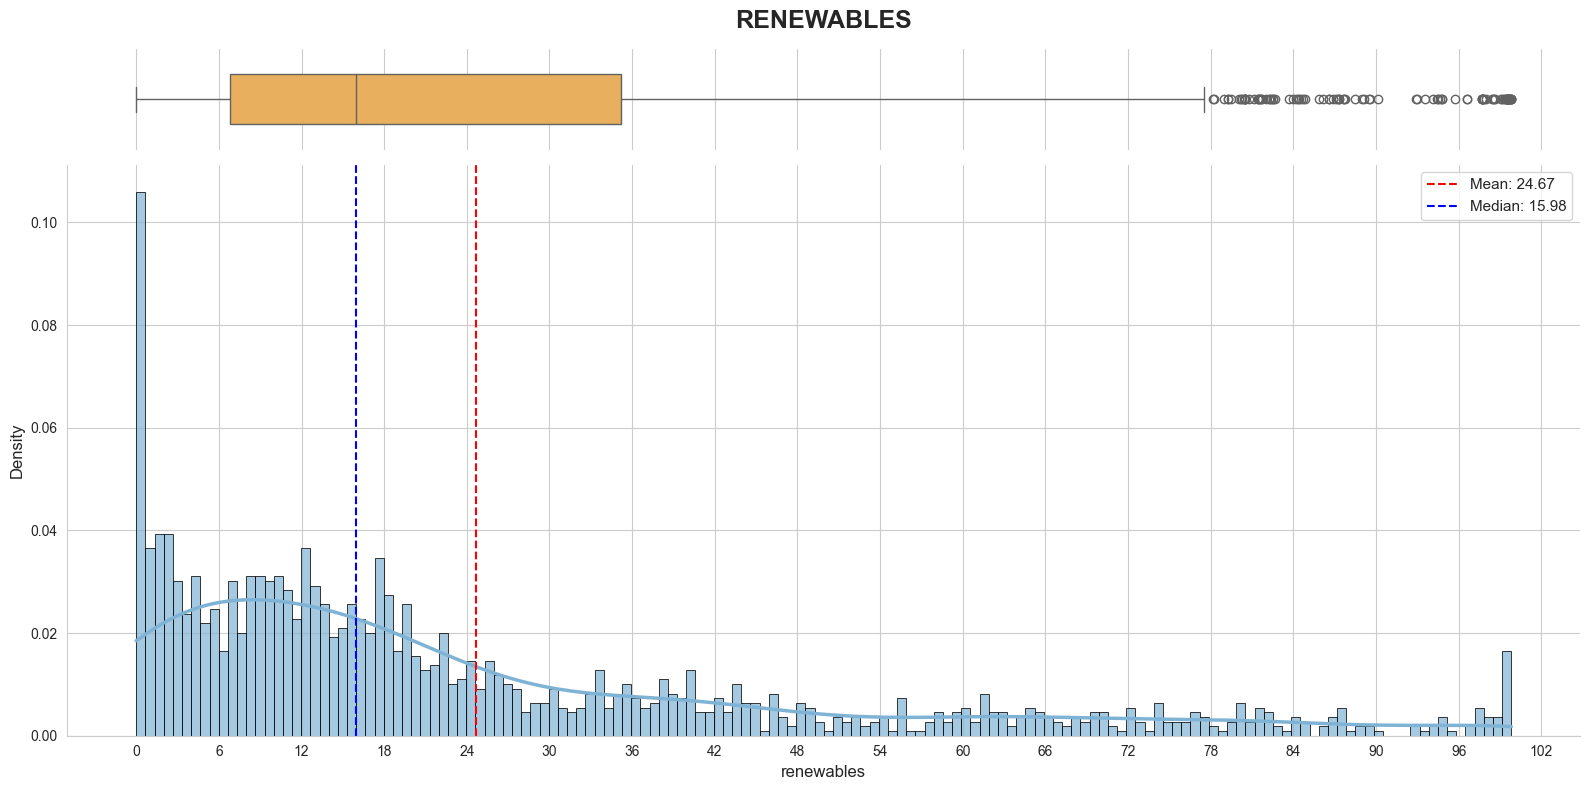

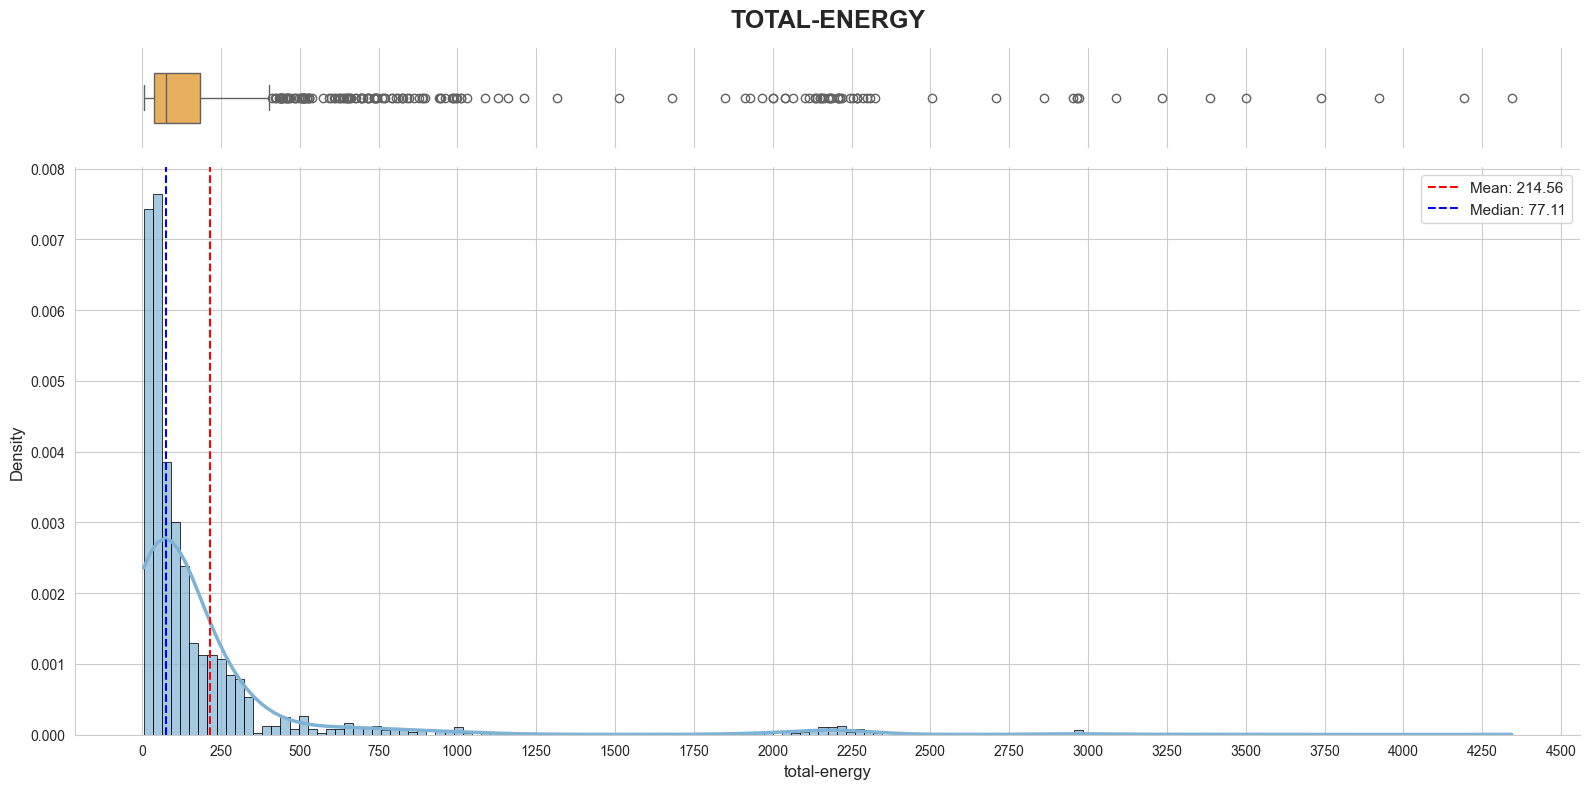

In [19]:
sns.set_style("whitegrid")
cols_to_plot = ['co2-emissions', 'coal-lignite', 'renewables', 'total-energy']

for col_name in cols_to_plot:
    fig, (ax_box, ax_hist) = plt.subplots(nrows=2, ncols=1, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(16, 8))
    
    sns.boxplot(data=df, x=col_name, ax=ax_box, color='#ffb347', width=0.5)
    
    ax_box.set_title(col_name.upper(), fontsize=18, pad=15, fontweight='bold')
    ax_box.set_xlabel('') 
    
    sns.histplot(data=df, x=col_name, bins=150, kde=True, stat='density', 
                 color='#7fb3d5', edgecolor='black', alpha=0.7, ax=ax_hist,
                 line_kws={'color': '#000080', 'linewidth': 2.5})
    
    mean_val = df[col_name].mean()
    median_val = df[col_name].median()
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax_hist.axvline(median_val, color='blue', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    

    ax_hist.xaxis.set_major_locator(ticker.MaxNLocator(20))
    ax_hist.set_xlabel(col_name, fontsize=12)
    ax_hist.set_ylabel('Density', fontsize=12)
    ax_hist.legend(loc='upper right', fontsize=11)
    

    for ax in [ax_box, ax_hist]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax_box.spines['left'].set_visible(False)
    ax_box.spines['bottom'].set_visible(False)
    ax_box.set_yticks([]) 

    plt.tight_layout()
    plt.show()

- Nhìn tổng thể, cả bốn đặc trưng đều có chung một hình thái phân phối là dữ liệu bị lệch phải rất mạnh

## 2. LÀM SẠCH VÀ CHUẨN HÓA DỮ LIỆU

## 3. MÃ HÓA DỮ LIỆU CHO DỮ LIỆU DANH MỤC

In [21]:
df = pd.read_csv('processed/processed_Scaled.csv')

le = LabelEncoder()
df['country'] = le.fit_transform(df['country'])

df.to_csv('processed/processed_Encoded.csv', index=False)
print("✅ Đã mã hóa xong và lưu vào 'processed/processed_Encoded.csv'!\n")

mapping_df = pd.DataFrame({
    'Mã số': range(len(le.classes_)),
    'Tên quốc gia': le.classes_
})

print("--- BẢNG ÁNH XẠ MÃ SỐ VÀ TÊN QUỐC GIA ---")
print(mapping_df.to_string(index=False))

✅ Đã mã hóa xong và lưu vào 'processed/processed_Encoded.csv'!

--- BẢNG ÁNH XẠ MÃ SỐ VÀ TÊN QUỐC GIA ---
 Mã số         Tên quốc gia
     0              Algeria
     1            Argentina
     2            Australia
     3           Azerbaijan
     4              Belgium
     5               Brazil
     6               Canada
     7                Chile
     8                China
     9             Colombia
    10              Czechia
    11              Denmark
    12                Egypt
    13               France
    14              Germany
    15                India
    16            Indonesia
    17                 Iran
    18                Italy
    19                Japan
    20           Kazakhstan
    21               Kuwait
    22             Malaysia
    23               Mexico
    24          Netherlands
    25          New Zealand
    26              Nigeria
    27               Norway
    28          Philippines
    29               Poland
    30             Portuga

## 4. XÂY DỰNG VÀ LỰA CHỌN ĐẶC TRƯNG

## 5. TRỰC QUAN HÓA MỐI QUAN HỆ GIỮA CÁC BIẾN DỮ LIỆU

## 6. KẾT LUẬN

## 7. TÀI LIỆU THAM KHẢO